# Análisis del portafolio — Lab 02 · Equipo 3

Solo carga `results/` y grafica con `src/plots.py`. Parte: P4.

In [1]:
import pickle
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

RESULTS = Path("..") / "results" / "portafolio.pkl"
FIGURES = Path("..") / "docs" / "figuras"
pd.set_option("display.width", 160)

with open(RESULTS, "rb") as archivo:
    resultados = pickle.load(archivo)

In [2]:
display(resultados["weight_stability"].round(4))

,AAPL,MSFT,META,AMD,XOM,SMH,GLD,COPX,mean_std,n_reviews
sample,0.0193,0.0224,0.0154,0.0172,0.0301,0.0125,0.0915,0.0132,0.0277,48
ewma,0.0205,0.0225,0.0157,0.0176,0.0282,0.0126,0.0915,0.0127,0.0277,48
ledoit_wolf,0.0181,0.0192,0.0116,0.0164,0.0268,0.0115,0.0724,0.0115,0.0234,48


,AAPL,MSFT,META,AMD,XOM,SMH,GLD,COPX,spread,ann_vol
risk_parity,0.1250,0.1250,0.1250,0.1250,0.1250,0.1250,0.1250,0.1250,0.0000,0.1664
equal,0.1305,0.1171,0.1343,0.2347,0.0873,0.1485,0.0163,0.1312,0.2188,0.2223


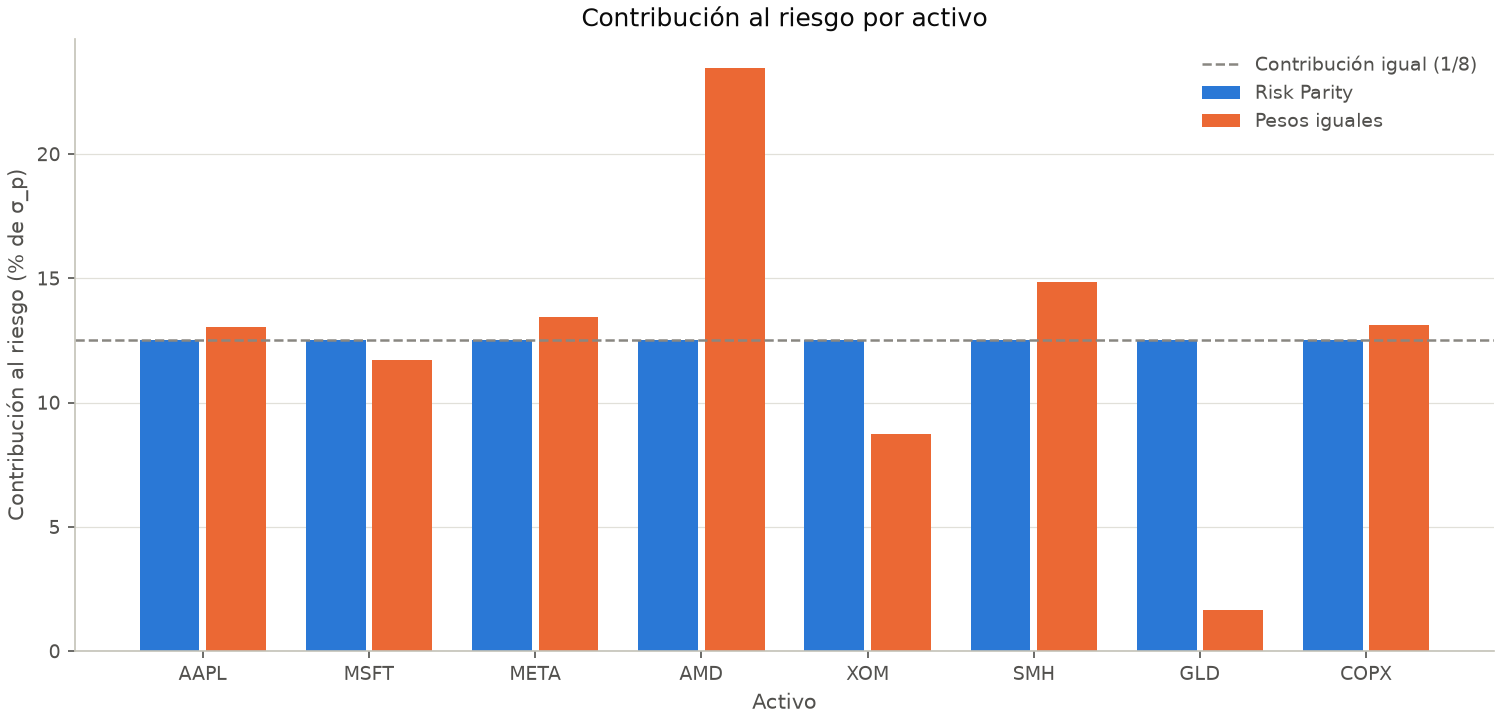

In [3]:
display(resultados["risk_contributions"].round(4))
display(Image(filename=FIGURES / "portafolio_contribuciones_riesgo.png"))

In [4]:
columnas = ["ann_return", "ann_vol", "sharpe", "calmar", "max_drawdown", "n_trades"]
display(resultados["performance"]["train"][columnas].round(3))

,ann_return,ann_vol,sharpe,calmar,max_drawdown,n_trades
risk_parity,0.001,0.013,0.063,0.030,-0.025,380
equal,0.003,0.013,0.254,0.170,-0.019,380
AAPL,0.049,0.045,1.100,0.775,-0.064,46
MSFT,-0.001,0.044,0.003,-0.009,-0.092,48
META,-0.009,0.053,-0.140,-0.116,-0.075,48
AMD,0.026,0.047,0.574,0.297,-0.088,57
XOM,0.008,0.044,0.203,0.057,-0.142,46
SMH,-0.013,0.045,-0.277,-0.175,-0.076,44
GLD,-0.019,0.044,-0.404,-0.183,-0.101,48
COPX,0.032,0.046,0.711,0.432,-0.075,49


,frequency,band,n_rebalances,turnover,gross_return,total_cost,net_return,n_trades
0,W,0.000,209,0.5991,0.0339,30011.0357,0.0039,380
1,W,0.025,88,0.4778,0.0335,29970.0807,0.0035,380
2,W,0.050,47,0.3878,0.0325,29830.0126,0.0027,380
3,W,0.100,20,0.2913,0.0316,29652.0461,0.0020,380
4,W,0.200,9,0.2445,0.0261,29533.2018,-0.0034,380
5,M,0.000,48,0.3914,0.0335,29892.7024,0.0036,380
6,M,0.025,40,0.3769,0.0332,29859.4065,0.0034,380
7,M,0.050,29,0.3457,0.0328,29835.6121,0.0030,380
8,M,0.100,18,0.3109,0.0319,29886.1002,0.0020,380
9,M,0.200,7,0.1991,0.0252,29597.9752,-0.0044,380


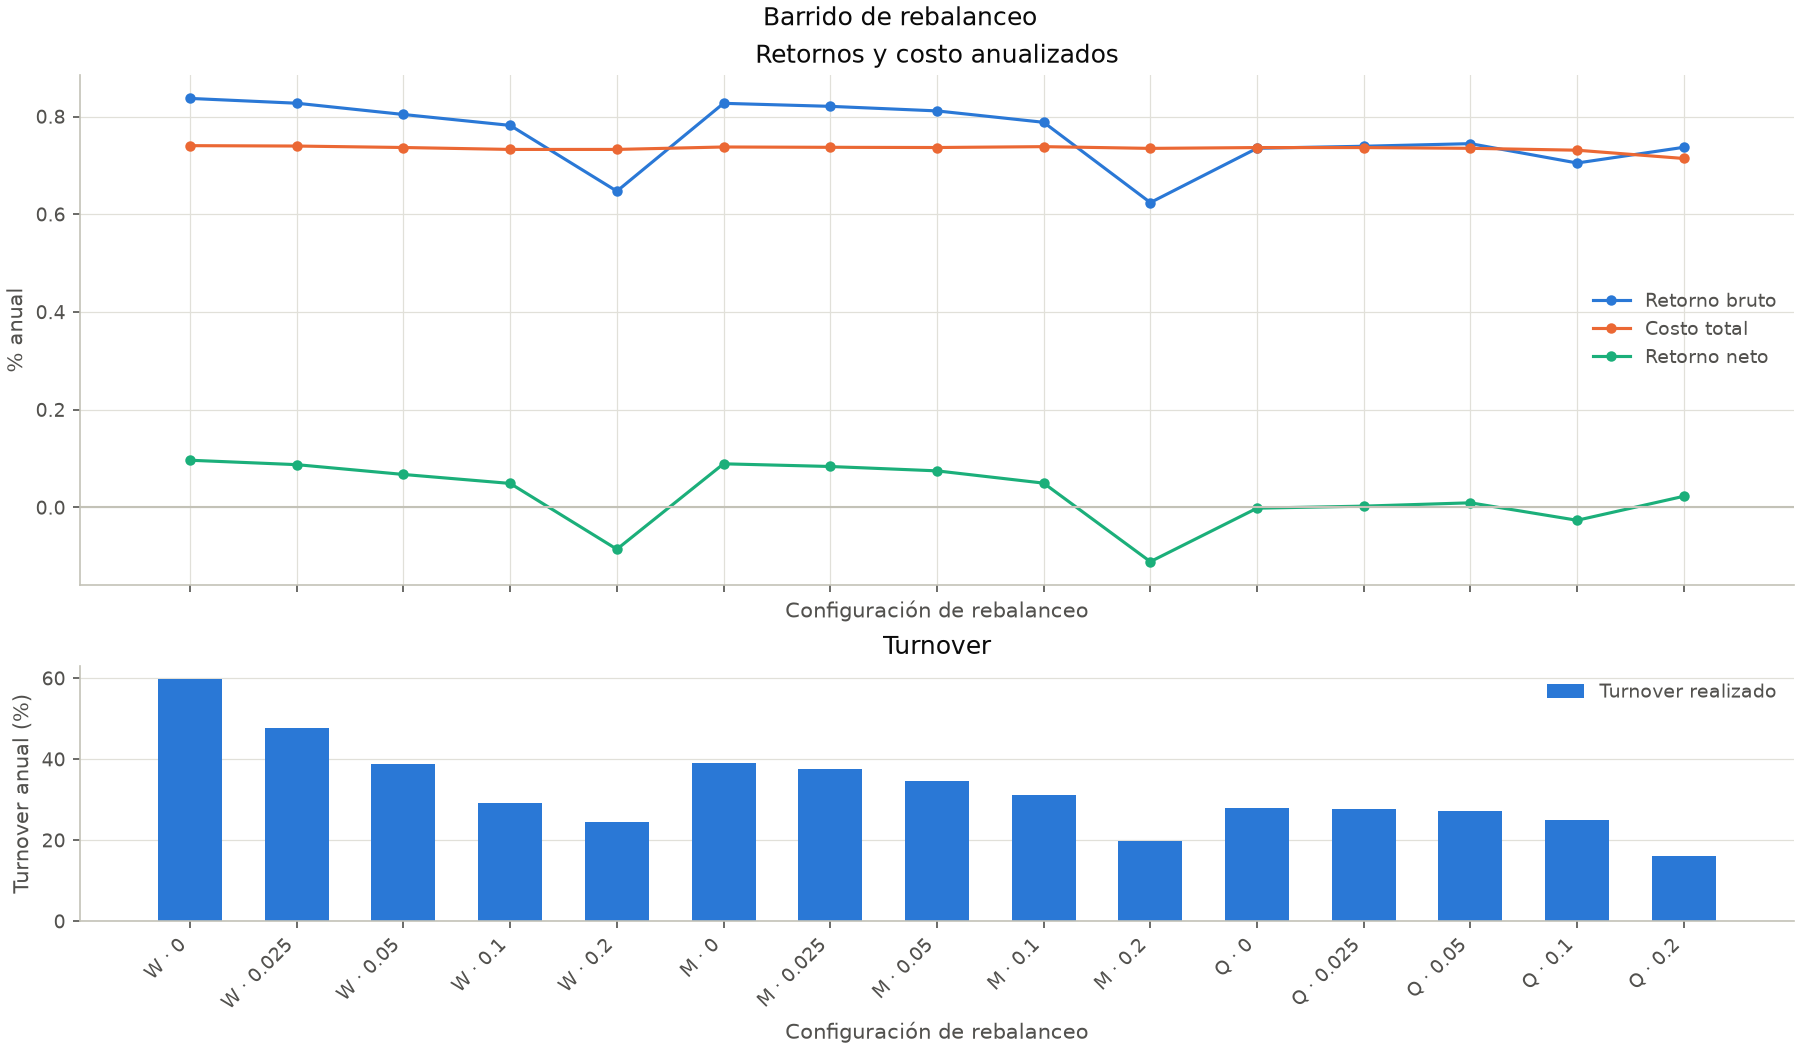

In [5]:
display(resultados["sweep"]["train"].round(4))
display(Image(filename=FIGURES / "portafolio_barrido_rebalanceo.png"))

## Limitaciones

- Todo es **preliminar**: θ base, solo bloque train, sin walk-forward. La elección de estimador, frecuencia y δ se hace una sola vez en validation con el θ final.
- El rebalanceo solo cambia el tamaño de las entradas nuevas (`resize_on_rebalance=False`), por eso el número de operaciones es igual en todo el barrido. Su costo se estima ex post con el turnover de los pesos.
- Los costos del barrido vienen sobre todo de las operaciones de señal, no del rebalanceo.
- La exposición es baja (C_i = 1/8 del capital y 1% de riesgo por operación), por eso los retornos y la volatilidad anuales son pequeños.